# Preprocessing Pipeline

Builds and validates the full image preprocessing pipeline shared by all model training notebooks and the Streamlit inference app.

## What this notebook does
1. Defines three custom transforms: grayscale-to-RGB conversion, CLAHE contrast enhancement, and Gaussian blur noise reduction
2. Composes them into `train_transforms` (with augmentation) and `val_test_transforms` (deterministic)
3. Loads datasets with `ImageFolder` and runs a **convolutional autoencoder per class** to identify and remove outlier images
4. Creates `DataLoader`s for all three splits
5. Visualises a sample batch to confirm the pipeline is working correctly

## Prerequisites
- `Class_Separation.ipynb` must have been run first so that `BACTERIAL_PNEUMONIA/` and `VIRAL_PNEUMONIA/` folders exist under each split
- Dataset must be placed at `datasets/chest_Xray/`

In [1]:
!pip install pillow
!pip install opencv-python
!pip install torch
!pip install torchvision
!pip install tqdm
!pip install matplotlib

In [2]:
import os
import cv2
import numpy as np
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from PIL import Image

In [3]:
DATA_DIR = "datasets/chest_Xray"
IMG_SIZE = 224
BATCH_SIZE = 64

## Load Data

Defines and composes the full preprocessing pipeline. Transforms are applied lazily by the `DataLoader` — each image is processed on-the-fly when a batch is requested, not pre-computed to disk.

The order of operations is significant: grayscale-to-RGB must run before CLAHE (which expects a valid image array), and `Normalize` must always run last after `ToTensor` has converted pixel values from `uint8` to float tensors.

### Contrast Enhancement — CLAHE

**Contrast Limited Adaptive Histogram Equalization (CLAHE)** improves the visibility of lung tissue features in chest X-rays.

Unlike global histogram equalization, CLAHE divides the image into a grid of tiles (`tileGridSize=(8,8)`) and equalises each tile independently. The `clipLimit=2.0` caps the contrast gain per tile, preventing over-amplification of noise in uniform regions.

For X-rays this is especially valuable: pathological features such as consolidation and infiltrates appear as subtle density changes that global approaches would either miss or wash out.

The function converts to grayscale for processing (CLAHE is a single-channel operation), applies enhancement, then converts back to 3-channel RGB — all three channels become identical copies of the enhanced grayscale.

In [4]:
def apply_clahe(img):
    img = np.array(img)

    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img)

    # Convert back to 3 channels
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    return Image.fromarray(img)

In [5]:
class CLAHETransform:
    def __call__(self, img):
        return apply_clahe(img)

### Noise Reduction — Gaussian Blur

A 3×3 Gaussian blur is applied after CLAHE to suppress high-frequency sensor noise that contrast enhancement can amplify.

`sigmaX=0` tells OpenCV to auto-compute sigma from the kernel size (≈0.85 for a 3×3 kernel), providing mild smoothing without blurring diagnostically relevant edge detail.

A `median` option is also implemented for salt-and-pepper noise; it is applied channel-wise to avoid colour artefacts. Gaussian is used by default as it better preserves edge gradients in radiographs.

In [6]:
def apply_noise_reduction(img, method="gaussian"):
    img_np = np.array(img)
    if method == "gaussian":
        # Gaussian blur: kernel size 3x3, sigma=0 (auto-computed)
        img_np = cv2.GaussianBlur(img_np, (3, 3), sigmaX=0)
    elif method == "median":
        # Median filtering: kernel size 3
        if len(img_np.shape) == 3:
            # Apply channel-wise for RGB
            img_np = np.stack(
                [cv2.medianBlur(img_np[:, :, c], 3) for c in range(img_np.shape[2])],
                axis=2
            )
        else:
            img_np = cv2.medianBlur(img_np, 3)
    return Image.fromarray(img_np)

In [7]:
class NoiseReductionTransform:
    def __init__(self, method="gaussian"):
        self.method = method
 
    def __call__(self, img):
        return apply_noise_reduction(img, method=self.method)

### Grayscale to RGB Conversion

Chest X-rays are inherently single-channel (grayscale). All pretrained backbones used in this project (ResNet50, EfficientNet-B4, ConvNeXt) expect 3-channel RGB input because they were pretrained on ImageNet.

This transform handles two cases:
- **2D array** (pure grayscale, shape `H×W`): duplicates to 3 channels via `cv2.COLOR_GRAY2RGB`
- **3D array with 1 channel** (shape `H×W×1`): uses `np.repeat` to expand to `H×W×3`

After conversion all three channels are identical. The model learns to operate on this uniform-channel representation during fine-tuning.

In [8]:
class GrayscaleToRGBTransform:
    def __call__(self, img):
        img = np.array(img)
        if len(img.shape) == 2:
            # Single-channel grayscale → duplicate to 3 channels
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        elif img.shape[2] == 1:
            img = np.repeat(img, 3, axis=2)
        return Image.fromarray(img)

### Transform Pipelines

Two pipelines are defined:

**`train_transforms`** — training only, includes random augmentations to improve generalisation:
- `RandomHorizontalFlip`: X-rays can be mirrored without changing pathology
- `RandomRotation(10°)`: accounts for slight patient positioning variation
- `RandomResizedCrop(scale=0.8–1.0)`: simulates zoom variation

**`val_test_transforms`** — validation, testing, and inference. Identical preprocessing but no randomness, ensuring deterministic and reproducible evaluation.

Both pipelines end with `ToTensor` and `Normalize` using standard ImageNet statistics `([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])`.

In [9]:
train_transforms = transforms.Compose([
    GrayscaleToRGBTransform(),
    CLAHETransform(),
    NoiseReductionTransform(method="gaussian"),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [10]:
val_test_transforms = transforms.Compose([
    GrayscaleToRGBTransform(),
    CLAHETransform(),
    NoiseReductionTransform(method="gaussian"),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [11]:
train_dataset = datasets.ImageFolder(
    root=os.path.join(DATA_DIR, "train"),
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    root=os.path.join(DATA_DIR, "val"),
    transform=val_test_transforms
)

test_dataset = datasets.ImageFolder(
    root=os.path.join(DATA_DIR, "test"),
    transform=val_test_transforms
)

## Identifying and Removing Outliers

A **convolutional autoencoder** is trained per class to identify images that do not belong — mislabelled scans, corrupted files, or genuinely anomalous cases that would harm training.

### How it works
1. For each class independently, a small 3-layer encoder/decoder is trained to reconstruct images of that class
2. After training, pixel-level MSE reconstruction error is computed for every image
3. Images in the top percentile of reconstruction error are removed — these are the samples the autoencoder found hardest to reconstruct, and therefore most likely to be outliers

### Thresholds
| Split | Threshold percentile | Removed |
|---|---|---|
| Train | 95th | Top 5% per class |
| Val / Test | 97th | Top 3% per class |

Per-class cleaning ensures that a class with legitimately different visual characteristics is not penalised relative to others.

In [12]:
import torch.nn as nn
from torch.utils.data import Subset
from tqdm import tqdm

In [13]:
class ConvAutoencoder(nn.Module):
    def __init__(self):
        super(ConvAutoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

In [14]:
def clean_dataset_with_autoencoder(dataset, epochs=3, threshold_percentile=95):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    all_indices_to_keep = []
    targets = np.array(dataset.targets)

    for cls in np.unique(targets):
        print(f"\nProcessing class {cls}...")

        cls_indices = np.where(targets == cls)[0]
        subset = Subset(dataset, cls_indices)

        loader = DataLoader(subset, batch_size=BATCH_SIZE, shuffle=True)

        model = ConvAutoencoder().to(device)
        criterion = nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

        # ---- TRAIN ----
        model.train()
        for epoch in range(epochs):
            total_loss = 0
            loop = tqdm(loader, desc=f"Class {cls} | Epoch {epoch+1}/{epochs}", leave=False)

            for imgs, _ in loop:
                imgs = imgs.to(device)

                outputs = model(imgs)
                loss = criterion(outputs, imgs)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                total_loss += loss.item()
                loop.set_postfix(loss=loss.item())

            print(f"Class {cls} Epoch {epoch+1}, Total Loss: {total_loss:.4f}")

        # ---- ERROR COMPUTATION ----
        model.eval()
        errors = []

        with torch.no_grad():
            for imgs, _ in tqdm(loader, desc=f"Error calc (Class {cls})", leave=False):
                imgs = imgs.to(device)
                outputs = model(imgs)

                batch_errors = torch.mean((imgs - outputs) ** 2, dim=[1,2,3])
                errors.extend(batch_errors.cpu().numpy())

        errors = np.array(errors)

        threshold = np.percentile(errors, threshold_percentile)
        keep_mask = errors < threshold
        keep_indices = cls_indices[keep_mask]

        print(f"Class {cls}: removed {len(cls_indices) - len(keep_indices)} samples")

        all_indices_to_keep.extend(keep_indices.tolist())

    all_indices_to_keep = sorted(all_indices_to_keep)

    dataset.samples = [dataset.samples[i] for i in all_indices_to_keep]
    dataset.targets = [dataset.targets[i] for i in all_indices_to_keep]

    return dataset

## Dataset Balancing

In [15]:
from torch.utils.data import Subset
import numpy as np

def balance_dataset(dataset, strategy="undersample"):
    """
    strategy:
        - "undersample" → reduce majority class
        - "oversample"   → duplicate minority classes (not recommended here)
    """

    targets = np.array(dataset.targets)
    classes, counts = np.unique(targets, return_counts=True)

    print("Before balancing:", dict(zip(classes, counts)))

    if strategy == "undersample":
        min_count = min(counts)

        keep_indices = []

        for cls in classes:
            cls_indices = np.where(targets == cls)[0]
            selected = np.random.choice(cls_indices, min_count, replace=False)
            keep_indices.extend(selected)

    elif strategy == "oversample":
        max_count = max(counts)

        keep_indices = []

        for cls in classes:
            cls_indices = np.where(targets == cls)[0]

            if len(cls_indices) < max_count:
                selected = np.random.choice(
                    cls_indices,
                    max_count,
                    replace=True
                )
            else:
                selected = cls_indices

            keep_indices.extend(selected)

    keep_indices = sorted(keep_indices)

    dataset.samples = [dataset.samples[i] for i in keep_indices]
    dataset.targets = [dataset.targets[i] for i in keep_indices]

    print("After balancing:", dict(zip(*np.unique(dataset.targets, return_counts=True))))

    return dataset

In [16]:
print("Cleaning datasets using autoencoder...")

train_dataset = clean_dataset_with_autoencoder(train_dataset, epochs=3, threshold_percentile=95)
val_dataset = clean_dataset_with_autoencoder(val_dataset, epochs=2, threshold_percentile=97)
test_dataset = clean_dataset_with_autoencoder(test_dataset, epochs=2, threshold_percentile=97)

print("\nBalancing train dataset...")
train_dataset = balance_dataset(train_dataset, strategy="undersample")

Cleaning datasets using autoencoder...

Processing class 0...


Class 0 Epoch 1, Total Loss: 32.3239


Class 0 Epoch 2, Total Loss: 22.5396


Class 0 Epoch 3, Total Loss: 17.9660


Class 0: removed 127 samples

Processing class 1...


...

Class 1 Epoch 2, Total Loss: 5.4484


Class 1: removed 8 samples

Processing class 2...


Class 2 Epoch 1, Total Loss: 4.0050


Class 2 Epoch 2, Total Loss: 3.9968


Class 2: removed 5 samples

Balancing train dataset...
Before balancing: {np.int64(0): np.int64(2403), np.int64(1): np.int64(1273), np.int64(2): np.int64(1277)}
After balancing: {np.int64(0): np.int64(1273), np.int64(1): np.int64(1273), np.int64(2): np.int64(1273)}


## DataLoader Preparation

Wraps the cleaned datasets in PyTorch `DataLoader`s for batched iteration during training.

- **Train loader**: `shuffle=True` randomises batch composition each epoch. Uses `num_workers=0` to avoid multiprocessing conflicts — the autoencoder cleaning step modifies `dataset.samples` in-place, which can cause issues with forked worker processes
- **Val / Test loaders**: `shuffle=False` for deterministic, reproducible evaluation metrics. Uses all available CPU cores (`os.cpu_count()`) for faster data loading
- **Batch size**: 64 for all loaders

In [17]:
my_num_workers = os.cpu_count()

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

In [18]:
print("Classes:", train_dataset.classes)
print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

Classes: ['BACTERIAL_PNEUMONIA', 'NORMAL', 'VIRAL_PNEUMONIA']
Train size: 3819
Validation size: 186
Test size: 604


## Visualise Preprocessing Output

Displays a batch of 6 training images after all transforms have been applied. Pixel values are partially denormalised before display using the first channel's mean/std (all three channels are identical after the grayscale-to-RGB step).

Use this cell to verify:
- Images load from the correct class folders
- CLAHE and Gaussian blur effects are visible (enhanced contrast, slight smoothing)
- No obviously corrupted or mismatched images appear
- Augmentations (flips, rotations, crops) produce visible variation across the 6 samples

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0376734].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0815775].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0696037].


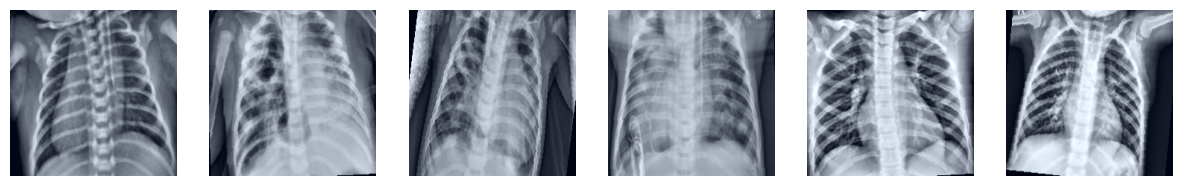

In [19]:
import matplotlib.pyplot as plt

def show_batch(loader):
    images, labels = next(iter(loader))
    images = images[:6]

    fig, axes = plt.subplots(1, 6, figsize=(15,5))
    for i in range(6):
        img = images[i].permute(1,2,0).numpy()
        img = (img * 0.229) + 0.485  # denormalize
        axes[i].imshow(img)
        axes[i].axis('off')

    plt.show()

show_batch(train_loader)

## Verifying Dataset Balance

In [20]:
from collections import Counter

def get_class_distribution(dataset, class_names):
    counts = Counter(dataset.targets)
    total = sum(counts.values())

    print("Class Distribution:\n")
    for i, name in enumerate(class_names):
        count = counts[i]
        percentage = (count / total) * 100
        print(f"{name}: {count} ({percentage:.2f}%)")

# Train
print("🔹 Train Dataset")
get_class_distribution(train_loader.dataset, train_loader.dataset.classes)

# Test
print("\n🔹 Test Dataset")
get_class_distribution(test_loader.dataset, test_loader.dataset.classes)

# Validation
print("🔹 Validation Dataset")
get_class_distribution(val_loader.dataset, val_loader.dataset.classes)

🔹 Train Dataset
Class Distribution:

BACTERIAL_PNEUMONIA: 1273 (33.33%)
NORMAL: 1273 (33.33%)
VIRAL_PNEUMONIA: 1273 (33.33%)

🔹 Test Dataset
Class Distribution:

BACTERIAL_PNEUMONIA: 234 (38.74%)
NORMAL: 227 (37.58%)
VIRAL_PNEUMONIA: 143 (23.68%)
🔹 Validation Dataset
Class Distribution:

BACTERIAL_PNEUMONIA: 62 (33.33%)
NORMAL: 62 (33.33%)
VIRAL_PNEUMONIA: 62 (33.33%)
